# Notebook 03 — Model Training & Evaluation
**Goal:** Train và so sánh các mô hình ML cho AML detection.

## Mô hình được đề xuất cho PaySim AML

| Model | Lý do chọn | Trade-off |
|---|---|---|
| **XGBoost** (Primary) | Tốt nhất cho tabular imbalanced, SHAP hỗ trợ native, fast inference ~1ms | Training chậm hơn LightGBM |
| **LightGBM** (Alternative) | Nhanh hơn XGBoost 3-5x khi train trên 6M rows, leaf-wise split | Dễ overfit nếu không tune |
| **Logistic Regression** (Baseline) | Interpretable, nhanh, chuẩn tham chiếu | Yếu với non-linear patterns |
| **Random Forest** (Baseline) | Robust, ít hyperparameter | Chậm inference, không có SHAP native |
| **Isolation Forest** (Unsupervised) | Không cần labels, detect novelty | Precision thấp, nhiều FP |

**Khuyến nghị cuối cùng: XGBoost làm production model, LightGBM làm fallback.**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from pathlib import Path
from time import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score
)
import xgboost as xgb
import lightgbm as lgb
import shap

sns.set_theme(style='whitegrid')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models/artifacts')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Load Processed Features

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'features_v1.parquet')

with open(PROCESSED_DIR / 'feature_cols.json') as f:
    config = json.load(f)

FEATURE_COLS = config['features']
TARGET_COL = config['target']

print(f'Dataset shape: {df.shape}')
print(f'Fraud rate: {df[TARGET_COL].mean():.4f}')

X = df[FEATURE_COLS]
y = df[TARGET_COL]

Dataset shape: (6362620, 27)
Fraud rate: 0.0013


## 2. Train/Val/Test Split (Stratified 70/15/15)

In [3]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Second split: 50/50 on temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,} rows | Fraud rate: {y_train.mean():.4f}')
print(f'Val:   {len(X_val):,} rows | Fraud rate: {y_val.mean():.4f}')
print(f'Test:  {len(X_test):,} rows | Fraud rate: {y_test.mean():.4f}')

# Class weight for imbalanced learning
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f'\nscale_pos_weight: {scale_pos_weight:.1f}')

Train: 4,453,834 rows | Fraud rate: 0.0013
Val:   954,393 rows | Fraud rate: 0.0013
Test:  954,393 rows | Fraud rate: 0.0013

scale_pos_weight: 773.7


## 3. Evaluation Helper

In [4]:
TARGET_METRICS = {
    'precision': 0.70,
    'recall': 0.60,
    'f1': 0.65,
    'auc_roc': 0.85,
    'auc_pr': 0.50,
}

def evaluate_model(name, model, X_eval, y_eval, threshold=0.5):
    """Full evaluation report for AML model."""
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        'model': name,
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'auc_roc': roc_auc_score(y_eval, y_prob),
        'auc_pr': average_precision_score(y_eval, y_prob),
        'fpr': (((y_pred == 1) & (y_eval == 0)).sum() / (y_eval == 0).sum()),
    }
    
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        if k == 'model': continue
        target = TARGET_METRICS.get(k)
        status = '✓' if (target is None or v >= target) else '✗'
        target_str = f'(target≥{target})' if target else ''
        print(f'  {k:12s}: {v:.4f} {status} {target_str}')
    
    return metrics, y_prob

results = {}

## 4. Model 1: Logistic Regression (Baseline)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

t0 = time()
lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
print(f'LR training time: {time()-t0:.1f}s')

# Wrap scaler + model for consistent API
from sklearn.pipeline import Pipeline
lr_pipeline = Pipeline([('scaler', scaler), ('model', lr)])

metrics_lr, prob_lr = evaluate_model('Logistic Regression', lr_pipeline, X_val, y_val)
results['LR'] = metrics_lr

LR training time: 34.5s



=== Logistic Regression ===
  precision   : 0.1093 ✗ (target≥0.7)
  recall      : 0.9886 ✓ (target≥0.6)
  f1          : 0.1969 ✗ (target≥0.65)
  auc_roc     : 0.9983 ✓ (target≥0.85)
  auc_pr      : 0.7766 ✓ (target≥0.5)
  fpr         : 0.0104 ✓ 


## 5. Model 2: Random Forest (Baseline)

In [6]:
t0 = time()
rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced_subsample',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
print(f'RF training time: {time()-t0:.1f}s')

metrics_rf, prob_rf = evaluate_model('Random Forest', rf, X_val, y_val)
results['RF'] = metrics_rf

pickle.dump(rf, open(MODELS_DIR / 'rf_baseline.pkl', 'wb'))

RF training time: 290.0s



=== Random Forest ===
  precision   : 1.0000 ✓ (target≥0.7)
  recall      : 0.9951 ✓ (target≥0.6)
  f1          : 0.9976 ✓ (target≥0.65)
  auc_roc     : 0.9999 ✓ (target≥0.85)
  auc_pr      : 0.9975 ✓ (target≥0.5)
  fpr         : 0.0000 ✓ 


## 6. Model 3: XGBoost (Primary)

In [7]:
xgb_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'eval_metric': 'aucpr',
    'early_stopping_rounds': 30,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'tree_method': 'hist',  # fast histogram method
}

t0 = time()
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print(f'XGBoost training time: {time()-t0:.1f}s')

metrics_xgb, prob_xgb = evaluate_model('XGBoost', xgb_model, X_val, y_val)
results['XGB'] = metrics_xgb

xgb_model.save_model(str(MODELS_DIR / 'xgb_aml_v1.json'))
print('Model saved: xgb_aml_v1.json')

[0]	validation_0-aucpr:0.99539


[50]	validation_0-aucpr:0.99655


[65]	validation_0-aucpr:0.99647


XGBoost training time: 33.2s



=== XGBoost ===
  precision   : 0.9504 ✓ (target≥0.7)
  recall      : 0.9959 ✓ (target≥0.6)
  f1          : 0.9727 ✓ (target≥0.65)
  auc_roc     : 0.9998 ✓ (target≥0.85)
  auc_pr      : 0.9967 ✓ (target≥0.5)
  fpr         : 0.0001 ✓ 
Model saved: xgb_aml_v1.json


## 7. Model 4: LightGBM (Alternative)

In [8]:
lgb_params = {
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.05,
    'scale_pos_weight': scale_pos_weight,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'num_leaves': 63,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
}

t0 = time()
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)
print(f'LightGBM training time: {time()-t0:.1f}s')

metrics_lgb, prob_lgb = evaluate_model('LightGBM', lgb_model, X_val, y_val)
results['LGB'] = metrics_lgb

lgb_model.booster_.save_model(str(MODELS_DIR / 'lgb_aml_v1.txt'))
print('Model saved: lgb_aml_v1.txt')

Training until validation scores don't improve for 30 rounds


[50]	valid_0's binary_logloss: 0.000735606


[100]	valid_0's binary_logloss: 0.00032493


[150]	valid_0's binary_logloss: 0.000237784


[200]	valid_0's binary_logloss: 0.000191838


...

[350]	valid_0's binary_logloss: 0.000158733


[400]	valid_0's binary_logloss: 0.000157211


[450]	valid_0's binary_logloss: 0.000156605


[500]	valid_0's binary_logloss: 0.000156387
Did not meet early stopping. Best iteration is:
[487]	valid_0's binary_logloss: 0.000156291
LightGBM training time: 104.7s



=== LightGBM ===
  precision   : 0.9943 ✓ (target≥0.7)
  recall      : 0.9951 ✓ (target≥0.6)
  f1          : 0.9947 ✓ (target≥0.65)
  auc_roc     : 0.9994 ✓ (target≥0.85)
  auc_pr      : 0.9960 ✓ (target≥0.5)
  fpr         : 0.0000 ✓ 
Model saved: lgb_aml_v1.txt


## 8. Comparison & Best Model Selection


=== MODEL COMPARISON ===
     precision  recall      f1  auc_roc  auc_pr     fpr
LR      0.1093  0.9886  0.1969   0.9983  0.7766  0.0104
RF      1.0000  0.9951  0.9976   0.9999  0.9975  0.0000
XGB     0.9504  0.9959  0.9727   0.9998  0.9967  0.0001
LGB     0.9943  0.9951  0.9947   0.9994  0.9960  0.0000

=== TARGET ACHIEVEMENT ===
LR: PARTIAL
RF: ALL TARGETS MET ✓
XGB: ALL TARGETS MET ✓
LGB: ALL TARGETS MET ✓


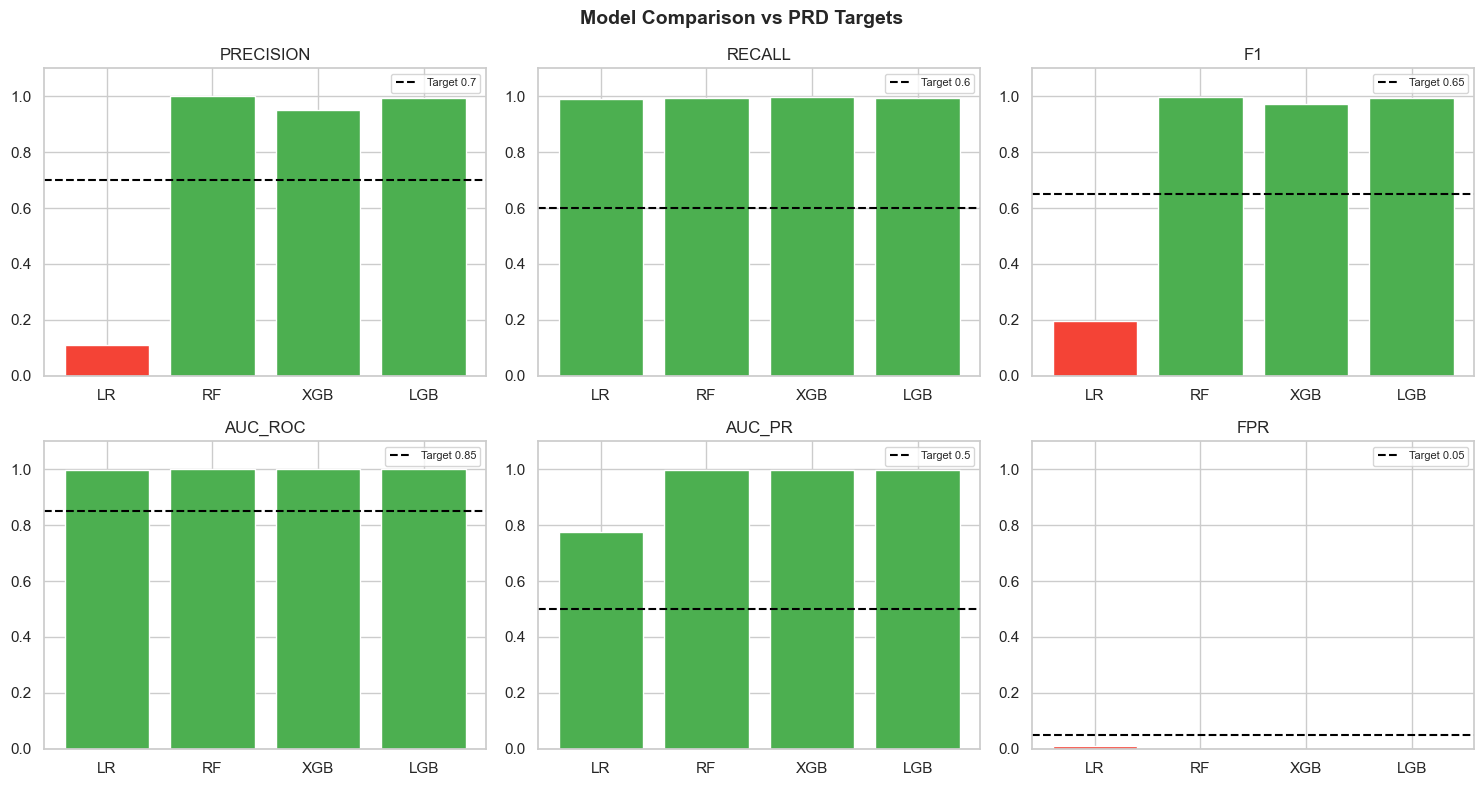

In [9]:
comparison = pd.DataFrame(results).T
comparison = comparison.drop('model', axis=1).astype(float)

print('\n=== MODEL COMPARISON ===')
print(comparison.round(4).to_string())

# Highlight which models meet targets
print('\n=== TARGET ACHIEVEMENT ===')
for model_name, row in comparison.iterrows():
    meets = all(row[k] >= v for k, v in TARGET_METRICS.items() if k in row)
    status = 'ALL TARGETS MET ✓' if meets else 'PARTIAL'
    print(f'{model_name}: {status}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_to_plot = ['precision', 'recall', 'f1', 'auc_roc', 'auc_pr', 'fpr']
targets_vals = [0.70, 0.60, 0.65, 0.85, 0.50, 0.05]

for ax, metric, target in zip(axes.flat, metrics_to_plot, targets_vals):
    vals = comparison[metric]
    colors = ['#4CAF50' if v >= target else '#F44336' for v in vals]
    ax.bar(vals.index, vals.values, color=colors)
    ax.axhline(target, color='black', linestyle='--', label=f'Target {target}')
    ax.set_title(f'{metric.upper()}')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)

plt.suptitle('Model Comparison vs PRD Targets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Threshold Tuning

Optimal threshold: 0.9111
At threshold 0.9111: P=1.0000, R=0.9951, F1=0.9976


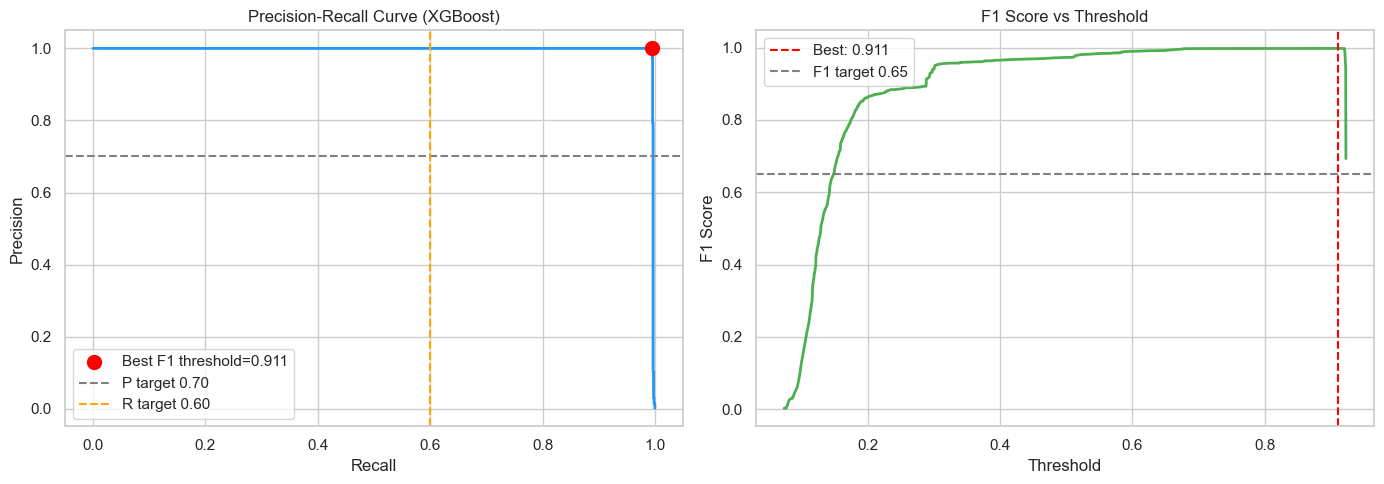

In [10]:
# Find optimal threshold for best F1
# Use XGBoost as primary model
prob_best = prob_xgb  # change to prob_lgb if LGB is better

precisions, recalls, thresholds = precision_recall_curve(y_val, prob_best)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Optimal threshold: {best_threshold:.4f}')
print(f'At threshold {best_threshold:.4f}: P={precisions[best_idx]:.4f}, R={recalls[best_idx]:.4f}, F1={best_f1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, color='#2196F3', lw=2)
axes[0].scatter([recalls[best_idx]], [precisions[best_idx]], color='red', s=100, zorder=5,
                label=f'Best F1 threshold={best_threshold:.3f}')
axes[0].axhline(0.70, linestyle='--', color='gray', label='P target 0.70')
axes[0].axvline(0.60, linestyle='--', color='orange', label='R target 0.60')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (XGBoost)')
axes[0].legend()

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='#4CAF50', lw=2)
axes[1].axvline(best_threshold, color='red', linestyle='--', label=f'Best: {best_threshold:.3f}')
axes[1].axhline(0.65, linestyle='--', color='gray', label='F1 target 0.65')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. SHAP Explainability

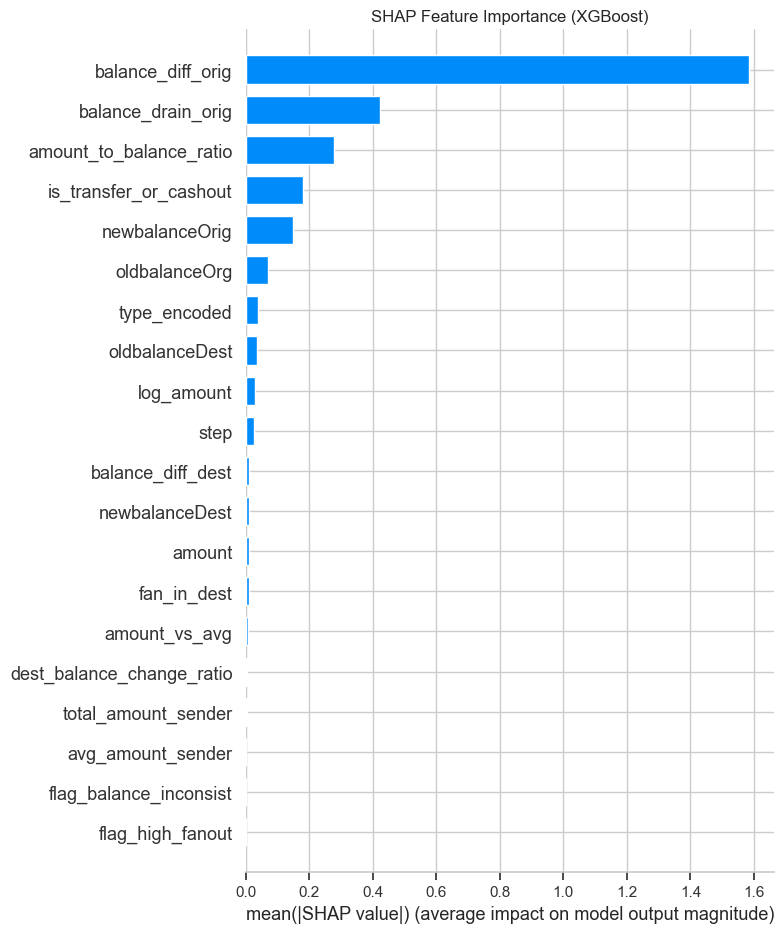

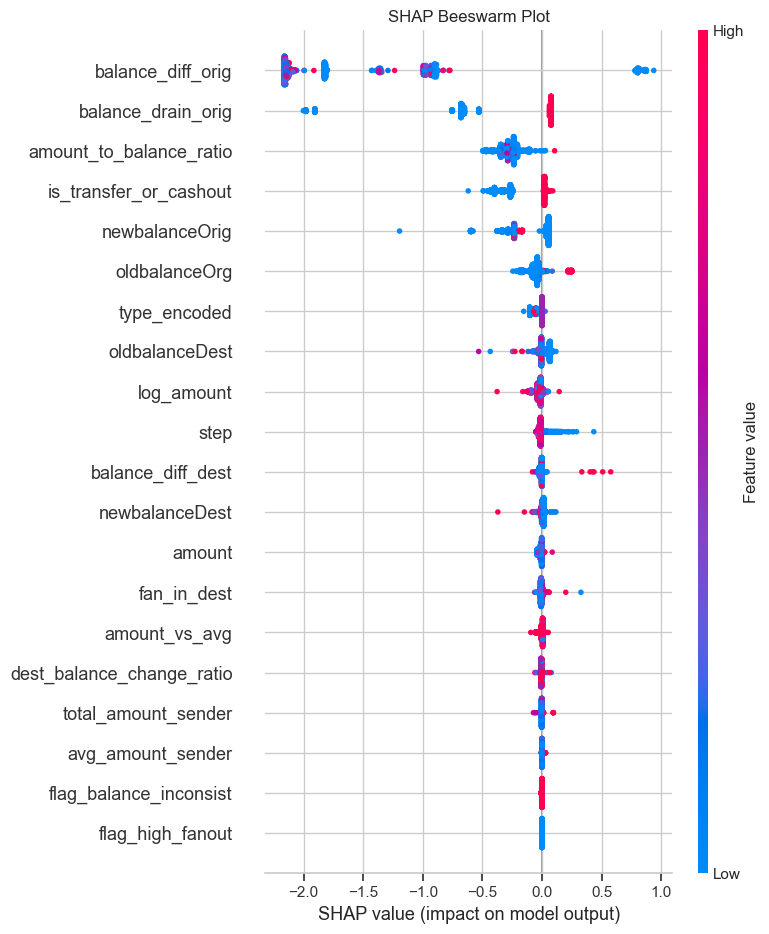

In [11]:
# SHAP analysis on test sample
SHAP_SAMPLE = 1000
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Beeswarm Plot')
plt.tight_layout()
plt.show()

## 11. Final Test Set Evaluation

=== FINAL TEST SET EVALUATION ===
(XGBoost with tuned threshold)


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    953161
       Fraud       1.00      1.00      1.00      1232

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393

AUC-ROC: 1.0000


AUC-PR:  0.9995
FPR:     0.0000 (target ≤ 0.05)


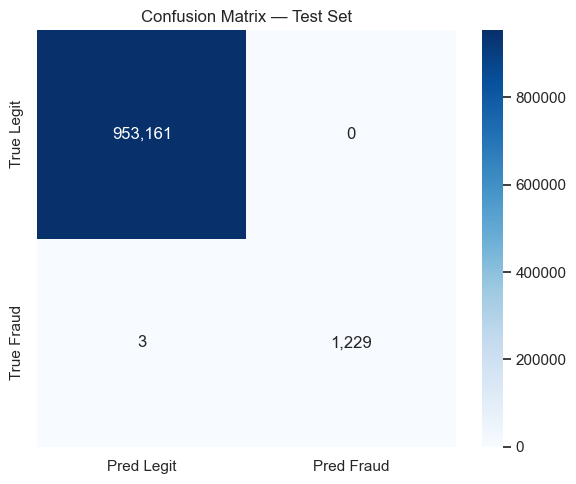


Saved model config to models/artifacts/model_config.json


In [12]:
print('=== FINAL TEST SET EVALUATION ===')
print('(XGBoost with tuned threshold)')

y_prob_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_test, target_names=['Legitimate', 'Fraud']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'AUC-PR:  {average_precision_score(y_test, y_prob_test):.4f}')
fpr_test = ((y_pred_test == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
print(f'FPR:     {fpr_test:.4f} (target ≤ 0.05)')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'])
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

# Save threshold config
model_config = {
    'model_version': 'xgb_aml_v1',
    'threshold_flag': float(best_threshold),
    'threshold_block': 0.85,
    'feature_cols': FEATURE_COLS,
    'auc_roc': roc_auc_score(y_test, y_prob_test),
    'auc_pr': average_precision_score(y_test, y_prob_test),
}
with open(MODELS_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print('\nSaved model config to models/artifacts/model_config.json')